In [1]:
import os
import sys
import random
import bentoml
import numpy as np
import pandas as pd
import pprint as pp
from pathlib import Path

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from models.transformer.preprocess import SequenceGenerator
from utils.dataset.config import DatasetPath
from utils.dataset.plot import show_items
from models.transformer.model import Model
from utils.retriever.ann import build_index, search

device = "cpu"

[INFO] Font applied: NanumGothic


# Load Dataset

In [2]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(base_dir=dataset_dir, dataset_name="fashion")

df_item = pd.read_parquet(paths.item_metadata_path)
df_user_logs = pd.read_parquet(paths.user_logs_path)
df_user_logs.head()

,user_id,item_id,timestamp,action,age,gender,name,brand_name,price,discount_price,...,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,description
0,1,2925,2025-09-21 03:01:00,click,46,Women,Vogue Women Pink Sunglasses,vogue,4930.0,4437.0,...,Pink,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,<p>This stylish range of vogue sunglasses are ...
1,1,2290,2025-09-21 03:02:00,click,46,Women,Idee Women Funky Eyewear Black Sunglasses,I DEE,1950.0,1755.0,...,Black,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,"<p>High on style, this pair of sunglasses from..."
2,1,1287,2025-09-21 03:05:00,click,46,Women,Idee Women Funky Eyewear Black Sunglasses,I DEE,1450.0,1305.0,...,Black,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,"<p>High on style, this pair of sunglasses from..."
3,1,7226,2025-09-21 03:04:00,click,46,Women,Miami Blues Women Sunglasses,Miami Blues,915.0,713.0,...,Purple,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,<p>NA</p>
4,1,868,2025-09-21 03:17:00,click,46,Women,United Colors of Benetton Women Sunglass,United Colors of Benetton,3450.0,3105.0,...,Black,Winter,2016,Casual,Accessories,Eyewear,Sunglasses,<UNK>,<UNK>,"<p><span style=""color: #000000 font-family;"">..."


# Load Model

In [3]:
# 모델 저장 디렉토리 경로
seq_model_dir = bentoml.models.get("transformer:latest").path
reg_model_dir = bentoml.models.get("regressor:latest").path

# 모델 객체 초기화
model = Model(seq_model_dir=seq_model_dir, reg_model_dir=reg_model_dir)

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


## Prediction Test

In [4]:
# 학습 데이터셋의 랜덤 유저를 추출하여 시퀀스 샘플 생성
user_id = random.choice(df_user_logs["user_id"].unique())
df_user_sample = df_user_logs[df_user_logs["user_id"] == user_id]
df_user_sample = df_user_sample.sort_values(by="user_id", ignore_index=True)

In [5]:
sequence_generator = SequenceGenerator(max_seq_len=model.seq_model_config["seq_len"])

feature_names = list(model.seq_model_config["feature_dims"].keys()) + ["item_id"]
target_names = list(model.seq_model_config["feature_dims"].keys())

df_seq_sample = sequence_generator.get_seq_dataframe(
    data=df_user_sample, feature_sequences=feature_names
)
df_seq_sample = df_seq_sample[df_seq_sample["seq_len"] == 5]
df_seq_sample

,user_id,user_rn,seq_len,mask,brand_name,gender,age_group,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,action,item_id,y_item_id
0,7623,1,5,"[0, 0, 0, 0, 0]","[Jealous 21, ONLY, Basics, Quiksilver, SPYKAR]","[Women, Women, Men, Men, Men]","[Adults-Women, Adults-Women, Adults-Men, Adult...","[Navy Blue, Pink, Grey, Blue, White]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Apparel]","[Bottomwear, Bottomwear, Topwear, Topwear, Top...","[Skirts, Skirts, Shirts, Shirts, Shirts]","[<UNK>, <UNK>, Regular Fit, Regular Fit, Regul...","[Casual, Casual, Casual, <UNK>, <UNK>]","[click, click, click, wishlist, click]","[8923, 2659, 2109, 4250, 9514]","[2659, 2109, 4250, 9514, 7759]"
1,7623,2,5,"[0, 0, 0, 0, 0]","[Elle, Femella, Jealous 21, ONLY, Basics]","[Women, Women, Women, Women, Men]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Blue, Red, Navy Blue, Pink, Grey]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Apparel]","[Bottomwear, Bottomwear, Bottomwear, Bottomwea...","[Skirts, Skirts, Skirts, Skirts, Shirts]","[<UNK>, <UNK>, <UNK>, <UNK>, Regular Fit]","[Casual, Formal, Casual, Casual, Casual]","[cart, cart, click, click, click]","[30, 5830, 8923, 2659, 2109]","[5830, 8923, 2659, 2109, 4250]"
2,7623,3,5,"[0, 0, 0, 0, 0]","[Femella, Jealous 21, ONLY, Basics, Quiksilver]","[Women, Women, Women, Men, Men]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Red, Navy Blue, Pink, Grey, Blue]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Apparel]","[Bottomwear, Bottomwear, Bottomwear, Topwear, ...","[Skirts, Skirts, Skirts, Shirts, Shirts]","[<UNK>, <UNK>, <UNK>, Regular Fit, Regular Fit]","[Formal, Casual, Casual, Casual, <UNK>]","[cart, click, click, click, wishlist]","[5830, 8923, 2659, 2109, 4250]","[8923, 2659, 2109, 4250, 9514]"
4,7623,5,5,"[0, 0, 0, 0, 0]","[Mineral, Elle, Femella, Jealous 21, ONLY]","[Women, Women, Women, Women, Women]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Brown, Blue, Red, Navy Blue, Pink]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Apparel]","[Bottomwear, Bottomwear, Bottomwear, Bottomwea...","[Skirts, Skirts, Skirts, Skirts, Skirts]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Ethnic, Casual, Formal, Casual, Casual]","[click, cart, cart, click, click]","[9076, 30, 5830, 8923, 2659]","[30, 5830, 8923, 2659, 2109]"
5,7623,6,5,"[0, 0, 0, 0, 0]","[Elle, Mineral, Elle, Femella, Jealous 21]","[Women, Women, Women, Women, Women]","[Adults-Women, Adults-Women, Adults-Women, Adu...","[Navy Blue, Brown, Blue, Red, Navy Blue]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Apparel, Apparel, Apparel]","[Bottomwear, Bottomwear, Bottomwear, Bottomwea...","[Skirts, Skirts, Skirts, Skirts, Skirts]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[Casual, Ethnic, Casual, Formal, Casual]","[click, click, cart, cart, click]","[2271, 9076, 30, 5830, 8923]","[9076, 30, 5830, 8923, 2659]"
7,7623,8,5,"[0, 0, 0, 0, 0]","[Red Tape, Baggit, Baggit, Fiorelli, Peperone]","[Men, Women, Women, Women, Women]","[Adults-Men, Adults-Women, Adults-Women, Adult...","[Brown, Yellow, Orange, Coffee Brown, Brown]","[Winter, Fall, Fall, Fall, Fall]","[2018, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Footwear, Accessories, Accessories, Accessori...","[Shoes, Wallets, Wallets, Wallets, Wallets]","[Casual Shoes, Wallets, Wallets, Wallets, Wall...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, wishlist, c

In [6]:
seq_sample = df_seq_sample.sample(1).to_dict(orient="records")[0]
seq_sample

{'user_id': 7623,
 'user_rn': 10,
 'seq_len': 5,
 'mask': [0, 0, 0, 0, 0],
 'brand_name': ['Red Chief', 'Skechers', 'Red Tape', 'Baggit', 'Baggit'],
 'gender': ['Men', 'Men', 'Men', 'Women', 'Women'],
 'age_group': ['Adults-Men',
  'Adults-Men',
  'Adults-Men',
  'Adults-Women',
  'Adults-Women'],
 'base_color': ['Brown', 'Brown', 'Brown', 'Yellow', 'Orange'],
 'season': ['Winter', 'Winter', 'Winter', 'Fall', 'Fall'],
 'year': ['2018', '2015', '2018', '2012', '2012'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'master_category': ['Footwear',
  'Footwear',
  'Footwear',
  'Accessories',
  'Accessories'],
 'sub_category': ['Shoes', 'Shoes', 'Shoes', 'Wallets', 'Wallets'],
 'article_type': ['Casual Shoes',
  'Casual Shoes',
  'Casual Shoes',
  'Wallets',
  'Wallets'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'occasion': ['<UNK>', 'Everyday', '<UNK>', '<UNK>', '<UNK>'],
 'action': ['cart', 'click', 'click', 'wishlist', 'click'],
 'item_id': [8546, 1459, 3

In [7]:
inputs = {}
for k in model.seq_model_config["feature_dims"].keys():
    inputs[k] = seq_sample[k]

pp.pprint(inputs)

{'action': ['cart', 'click', 'click', 'wishlist', 'click'],
 'age_group': ['Adults-Men',
               'Adults-Men',
               'Adults-Men',
               'Adults-Women',
               'Adults-Women'],
 'article_type': ['Casual Shoes',
                  'Casual Shoes',
                  'Casual Shoes',
                  'Wallets',
                  'Wallets'],
 'base_color': ['Brown', 'Brown', 'Brown', 'Yellow', 'Orange'],
 'brand_name': ['Red Chief', 'Skechers', 'Red Tape', 'Baggit', 'Baggit'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'gender': ['Men', 'Men', 'Men', 'Women', 'Women'],
 'master_category': ['Footwear',
                     'Footwear',
                     'Footwear',
                     'Accessories',
                     'Accessories'],
 'occasion': ['<UNK>', 'Everyday', '<UNK>', '<UNK>', '<UNK>'],
 'season': ['Winter', 'Winter', 'Winter', 'Fall', 'Fall'],
 'sub_category': ['Shoes', 'Shoes', 'Shoes', 'Wallets', 'Wallets'],
 'usage': ['Casual', '

In [8]:
# 예시 입력: user_id와 시퀀스
body = [{"user_id": 123, "inputs": inputs}]

# Model.predict 호출 -> Transformer + Projection 결과 생성
prediction = model.predict(body)[0]
pp.pprint(prediction)
# 출력: {"outputs": feature별 예측 값, "seq_vector": [...], "item_vector": [...]}

{'item_vector': [0.05019402876496315,
                 0.029240984469652176,
                 0.019740838557481766,
                 -0.020202526822686195,
                 -0.051631711423397064,
                 -0.0016449919203296304,
                 0.0702204778790474,
                 -0.00621003657579422,
                 -0.0494006909430027,
                 -0.007544220425188541,
                 0.005455344915390015,
                 0.018884258344769478,
                 0.0009521811734884977,
                 -0.003931873477995396,
                 0.03017829917371273,
                 0.02138049155473709,
                 0.026719896122813225,
                 -0.022764116525650024,
                 0.007104792632162571,
                 0.04273098334670067,
                 0.0808623805642128,
                 0.04160701110959053,
                 0.056229811161756516,
                 0.009873783215880394,
                 0.012220011092722416,
                 0.02104663

# Recommendation

In [9]:
# 이미지 기반 아이템 벡터 로드
df_image_vectors = pd.read_parquet(paths.image_vectors_path)

# text_vectors: (num_items, dim) numpy float32 배열
image_vectors = np.array(df_image_vectors["image_vector"].tolist())
image_vectors = np.array(image_vectors).astype(np.float32)

# {item index: item_id} 매핑
# (`df_text_vectors.index는` row index이므로 range(0..N-1)로 반환함)
item_id_maps = dict(zip(df_image_vectors["item_id"].index, df_image_vectors["item_id"]))

In [10]:
# 아이템 벡터 ANN 인덱스 생성
item_index = build_index(image_vectors)

In [11]:
# projection 모델에서 뽑은 item vector
query_vector = np.array(prediction["item_vector"])

# 아이템 벡터 인덱스에 질의한 결과 획득
result = search(query_vector, item_index, top_k=30)

# 추천 아이템 Index (원본 ID가 아닌 별도의 인덱스)
item_indies = list(result.keys())

# 추천 아이템 ID 재매핑
recommendation = {}
for i in item_indies:
    # 원본 ID로 매핑
    item_id = item_id_maps[i]
    recommendation[item_id] = result[i]

recommendation

{4177: 0.3733341097831726,
 9117: 0.3714621663093567,
 5919: 0.36960387229919434,
 643: 0.36764997243881226,
 754: 0.3623102307319641,
 6357: 0.35361552238464355,
 9425: 0.35264986753463745,
 1604: 0.34829580783843994,
 6129: 0.3460026979446411,
 2991: 0.34558355808258057,
 704: 0.3439484238624573,
 121: 0.3436070680618286,
 957: 0.338434100151062,
 9704: 0.33565568923950195,
 1826: 0.3354949355125427,
 7532: 0.33506226539611816,
 1707: 0.3324832320213318,
 4663: 0.32953834533691406,
 7113: 0.3282206058502197,
 445: 0.3234684467315674,
 3979: 0.3222682476043701,
 2716: 0.32089459896087646,
 5846: 0.320339560508728,
 2301: 0.31921470165252686,
 1794: 0.3190542459487915,
 2512: 0.31710731983184814,
 6180: 0.3166350722312927,
 1471: 0.31485486030578613,
 3965: 0.31406885385513306,
 1298: 0.313403844833374}

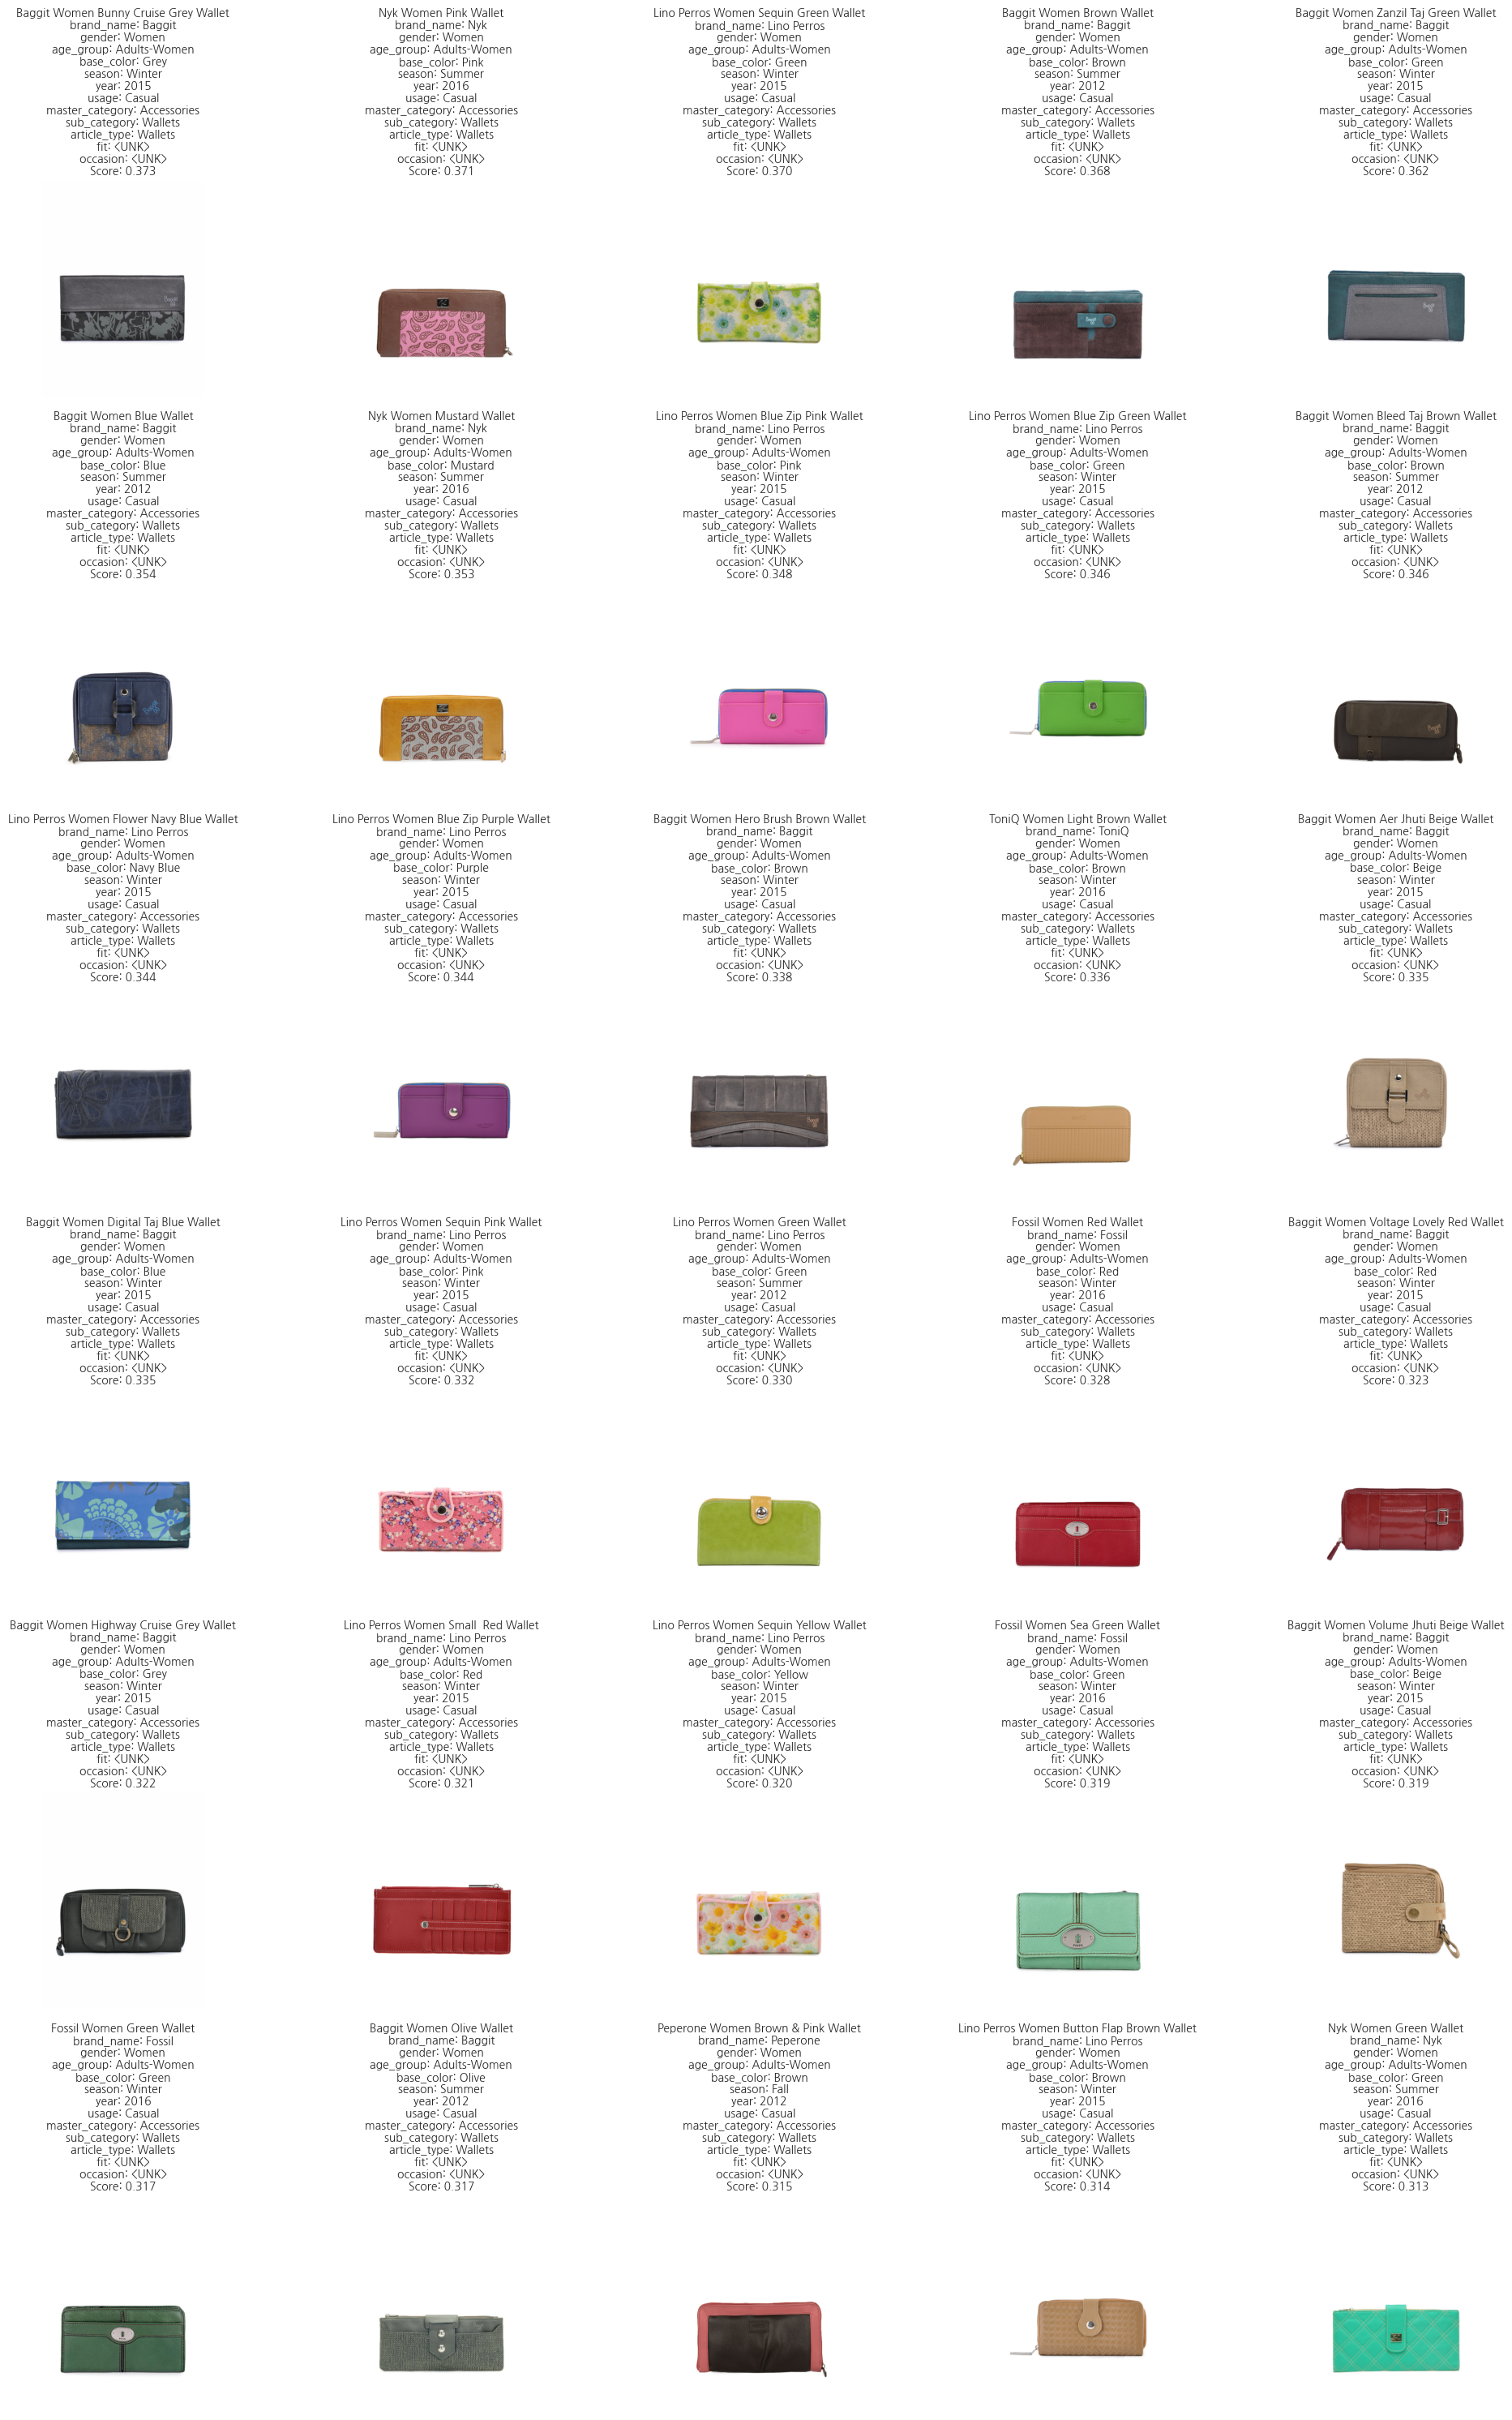

In [12]:
# 추천 아이템 후보군 상세 보기
show_items(
    item_ids=list(recommendation.keys()),
    df_item=df_item,
    attributes=tuple(model.seq_model_config["feature_dims"].keys()),
    scores=list(recommendation.values()),
    image_dir=paths.base_path.joinpath("images"),
)